In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [5]:
# Set plot style
sns.set_theme(style="whitegrid")

In [11]:
# Load the dataset
df = pd.read_csv(r"C:\Users\user\Downloads\online_retail_II.csv")

In [13]:
# Preview the data
display(df.head())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [14]:
# 1. Drop rows with missing Customer IDs (we can't segment unknown customers)
df = df.dropna(subset=['Customer ID'])

In [15]:
# 2. Remove cancelled orders (Quantity or Price less than 0)
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

In [16]:
# 3. Create a Total Sales column (Quantity * Price)
df['TotalSales'] = df['Quantity'] * df['Price']

In [17]:
# 4. Convert InvoiceDate to datetime format for time-based calculations
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Data cleaned! Total rows remaining: {len(df)}")

Data cleaned! Total rows remaining: 805549


In [18]:
# Set a 'snapshot date' which is one day after the last transaction in the dataset
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [19]:
# Group by Customer ID and calculate RFM
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'Invoice': 'nunique',                                    # Frequency
    'TotalSales': 'sum'                                      # Monetary Value
})

In [20]:
# Rename columns for clarity
rfm.rename(columns={'InvoiceDate': 'Recency',
                    'Invoice': 'Frequency',
                    'TotalSales': 'Monetary'}, inplace=True)

display(rfm.head())

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [21]:
# 1. Handle skewness with Log Transformation
rfm_log = np.log1p(rfm)

In [22]:
# 2. Scale the data so all variables have equal weight
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

In [23]:
# 3. Apply K-Means Clustering (We'll segment them into 4 groups)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(rfm_scaled)

,n_clusters,4
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [25]:
# 4. Assign the cluster labels back to our original RFM dataframe
rfm['Cluster'] = kmeans.labels_

In [26]:
# View the average RFM values for each customer cluster
cluster_summary = rfm.groupby('Cluster').mean().round(2)
display(cluster_summary)

,Recency,Frequency,Monetary
Cluster,,,
0,27.43,19.34,11014.37
1,395.86,1.38,325.75
2,227.87,5.10,2002.10
3,28.44,3.04,865.11


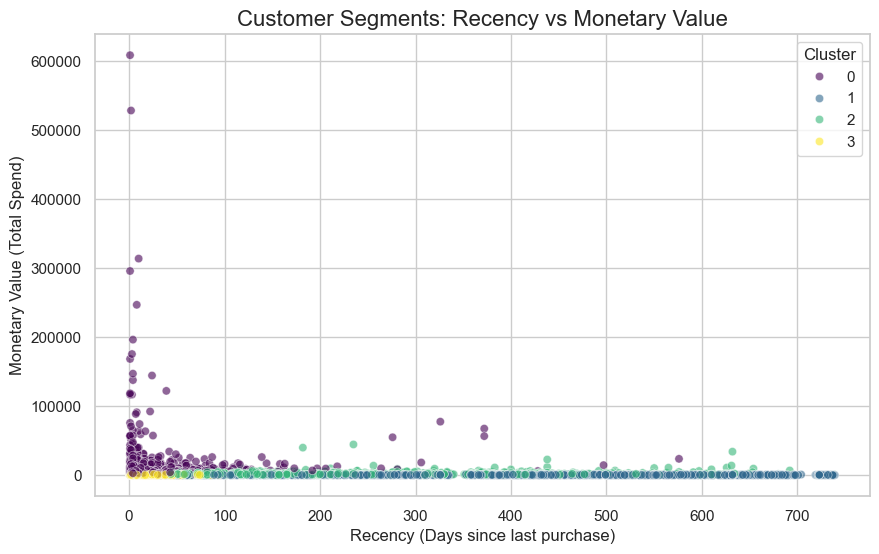

In [27]:
# Create a scatter plot of Recency vs Monetary Value, colored by Cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='viridis', alpha=0.6)
plt.title('Customer Segments: Recency vs Monetary Value', fontsize=16)
plt.xlabel('Recency (Days since last purchase)')
plt.ylabel('Monetary Value (Total Spend)')
plt.legend(title='Cluster')
plt.show()